# Book Recommender Project

Books Scrapped from [goodreads](https://www.goodreads.com/book/popular_by_date/2019).

Developed by: Bryan Calderon

Extracting the 10 most popular books per year!

#### EDA

* Importing libraries

In [18]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from urllib.parse import urljoin
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df2 = pd.read_csv("data/raw/goodreads_books_detailed1.csv")
df2

In [7]:
df2.describe()

,source_year,rank,average_rating,ratings_count,reviews_count,pages
count,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000
mean,1999.500000,5.500000,4.111660,1.025225e+06,58352.538000,409.122000
std,14.445322,2.875158,0.218864,1.171076e+06,64478.979795,191.464002
min,1975.000000,1.000000,3.470000,3.071200e+04,371.000000,32.000000
25%,1987.000000,3.000000,3.970000,3.003502e+05,11678.250000,290.250000
50%,1999.500000,5.500000,4.110000,7.181100e+05,32704.000000,374.000000
75%,2012.000000,8.000000,4.270000,1.253885e+06,86415.250000,483.500000
max,2024.000000,10.000000,4.660000,1.163572e+07,405524.000000,1312.000000


In [8]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   source_year     500 non-null    int64  
 1   rank            500 non-null    int64  
 2   list_title      500 non-null    str    
 3   book_url        500 non-null    str    
 4   source          500 non-null    str    
 5   title           500 non-null    str    
 6   author          500 non-null    str    
 7   average_rating  500 non-null    float64
 8   ratings_count   500 non-null    int64  
 9   reviews_count   500 non-null    int64  
 10  description     500 non-null    str    
 11  genres          500 non-null    str    
 12  pages           500 non-null    int64  
 13  published_date  500 non-null    str    
 14  image_url       500 non-null    str    
dtypes: float64(1), int64(5), str(9)
memory usage: 681.6 KB


In [3]:
df2["list_title"].value_counts()

list_title
ACE #1                                           4
The BFG                                          2
Matilda                                          2
’Salem’s Lot                                     1
Tuck Everlasting                                 1
                                                ..
Just for the Summer (Part of Your World, #3)     1
The Housemaid is Watching (The Housemaid, #3)    1
Quicksilver (Fae & Alchemy, #1)                  1
The Teacher                                      1
The Boyfriend                                    1
Name: count, Length: 495, dtype: int64

* Cleaning dataset

In [4]:
df2.isna().sum()

source_year       0
rank              0
list_title        0
book_url          0
source            0
title             0
author            0
average_rating    0
ratings_count     0
reviews_count     0
description       0
genres            0
pages             0
published_date    0
image_url         0
dtype: int64

In [6]:
df2.duplicated().sum()

np.int64(0)

In [9]:
df2["genres"].value_counts()

genres
Fantasy, Fiction, Young Adult, Harry Potter, Magic, Audiobook, Childrens                       7
Fantasy, Young Adult, Romance, Paranormal, Urban Fantasy, Fiction, Vampires                    5
Fantasy, Fiction, Epic Fantasy, Audiobook, High Fantasy, Science Fiction Fantasy, Adventure    4
Young Adult, Dystopia, Fiction, Fantasy, Science Fiction, Romance, Adventure                   4
Fiction, Thriller, Mystery, Crime, Suspense, Legal Thriller, Mystery Thriller                  3
                                                                                              ..
Romance, Audiobook, Fiction, Contemporary, Book Club, Contemporary Romance, Adult              1
Mystery, Fiction, Book Club, Thriller, Audiobook, Mystery Thriller, Historical Fiction         1
Romance, Audiobook, Fiction, Contemporary, Summer, Contemporary Romance, Book Club             1
Thriller, Mystery, Audiobook, Fiction, Mystery Thriller, Suspense, Crime                       1
Fantasy, Romantasy, Rom

In [ ]:
df2["author"].value_counts().head(10)
# Here also can say that the number of books by author

author
Stephen  King      22
Sarah J. Maas      13
Roald Dahl          8
J.K. Rowling        8
Stephenie Meyer     7
Colleen Hoover      7
Neil Gaiman         6
Rick Riordan        6
Cassandra Clare     6
Freida McFadden     6
Name: count, dtype: int64

<Axes: xlabel='average_rating', ylabel='Count'>

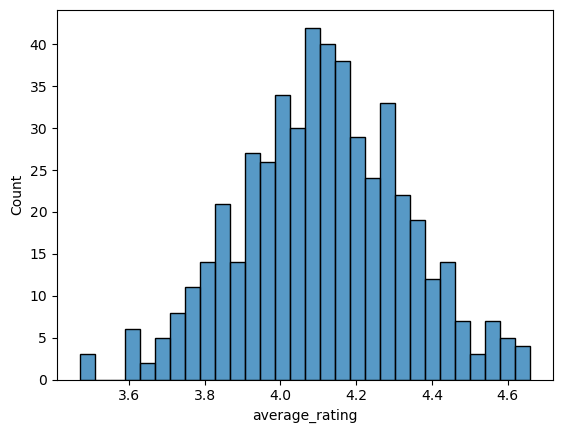

In [ ]:
sns.histplot(df2["average_rating"], bins=30)

In [20]:
top_popular_books = (
    df2.sort_values("ratings_count", ascending=False)
    [["title", "author", "source_year", "average_rating", "ratings_count"]]
    .head(10)
)

top_popular_books

,title,author,source_year,average_rating,ratings_count
220,Harry Potter and the Philosopher's Stone,J.K. Rowling,1997,4.47,11635724
330,The Hunger Games,Suzanne Collins,2008,4.35,10120960
300,Twilight,Stephenie Meyer,2005,3.68,7426050
370,The Fault in Our Stars,John Green,2012,4.12,5813639
240,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,1999,4.58,4956577
410,It Ends with Us,Colleen Hoover,2016,4.07,4743702
230,Harry Potter and the Chamber of Secrets,J.K. Rowling,1998,4.43,4591042
360,Divergent,Veronica Roth,2011,4.13,4442400
400,A Court of Thorns and Roses,Sarah J. Maas,2015,4.15,4426212
250,Harry Potter and the Goblet of Fire,J.K. Rowling,2000,4.57,4282921


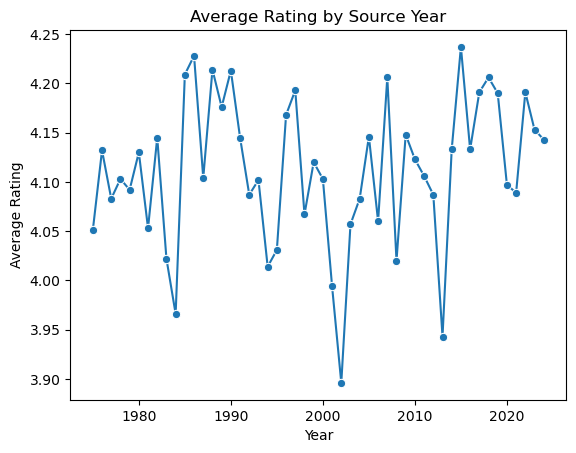

In [26]:
avg_rating_year = (df2.groupby("source_year")["average_rating"]
    .mean()
    .reset_index()
)

sns.lineplot(data=avg_rating_year,
    x="source_year",
    y="average_rating",
    marker="o"
)
plt.title("Average Rating by Source Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()


<Axes: xlabel='pages', ylabel='Count'>

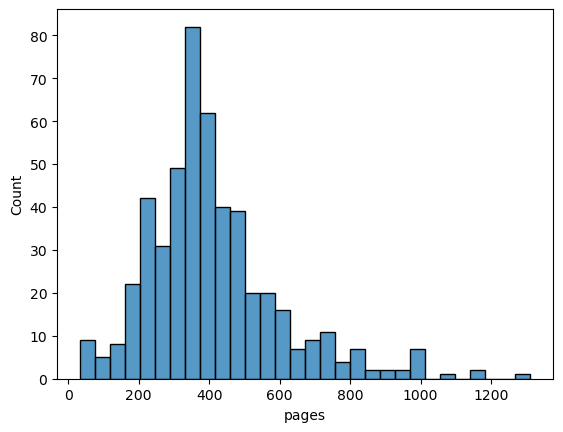

In [27]:
sns.histplot(df2["pages"], bins=30)

                   pages  average_rating
pages           1.000000        0.261364
average_rating  0.261364        1.000000


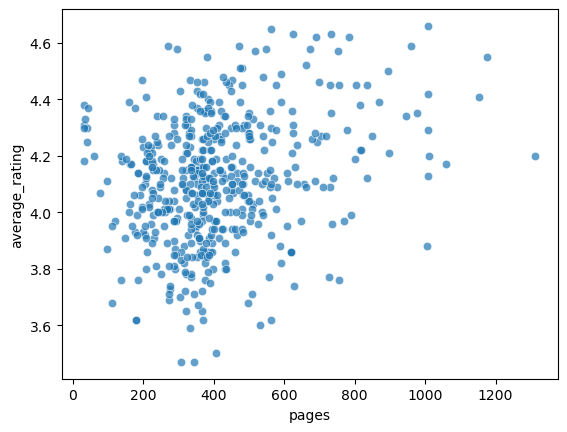

In [33]:
sns.scatterplot(
    data=df2,
    x="pages",
    y="average_rating",
    alpha=0.7)

print(df2[["pages", "average_rating"]].corr())

In [36]:
df_genres = df2.copy()

df_genres["genres"] = df_genres["genres"].str.split(", ")

df_genres = df_genres.explode("genres")

df_genres.head()

,source_year,rank,list_title,book_url,source,title,author,average_rating,ratings_count,reviews_count,description,genres,pages,published_date,image_url
0,1975,1,’Salem’s Lot,https://www.goodreads.com/book/show/11590._Sal...,Goodreads Popular by Year,’Salem’s Lot,Stephen King,4.1,674093,28812,Librarian's Note: Alternate-cover edition for ...,Horror,483,"October 17, 1975",https://m.media-amazon.com/images/S/compressed...
0,1975,1,’Salem’s Lot,https://www.goodreads.com/book/show/11590._Sal...,Goodreads Popular by Year,’Salem’s Lot,Stephen King,4.1,674093,28812,Librarian's Note: Alternate-cover edition for ...,Fiction,483,"October 17, 1975",https://m.media-amazon.com/images/S/compressed...
0,1975,1,’Salem’s Lot,https://www.goodreads.com/book/show/11590._Sal...,Goodreads Popular by Year,’Salem’s Lot,Stephen King,4.1,674093,28812,Librarian's Note: Alternate-cover edition for ...,Vampires,483,"October 17, 1975",https://m.media-amazon.com/images/S/compressed...
0,1975,1,’Salem’s Lot,https://www.goodreads.com/book/show/11590._Sal...,Goodreads Popular by Year,’Salem’s Lot,Stephen King,4.1,674093,28812,Librarian's Note: Alternate-cover edition for ...,Fantasy,483,"October 17, 1975",https://m.media-amazon.com/images/S/compressed...
0,1975,1,’Salem’s Lot,https://www.goodreads.com/book/show/11590._Sal...,Goodreads Popular by Year,’Salem’s Lot,Stephen King,4.1,674093,28812,Librarian's Note: Alternate-cover edition for ...,Thriller,483,"October 17, 1975",https://m.media-amazon.com/images/S/compressed...


In [39]:
df_genres.shape

(3501, 15)

In [ ]:
top_genres = (
    df_genres["genres"]
    .value_counts()
    .head(15)
    .reset_index())

top_genres.columns = ["genre", "book_count"]

top_genres

,genre,book_count
0,Fiction,425
1,Audiobook,220
2,Fantasy,208
3,Romance,158
4,Young Adult,137
5,Classics,129
6,Book Club,124
7,Contemporary,116
8,Mystery,99
9,Thriller,88


<Axes: xlabel='book_count', ylabel='genre'>

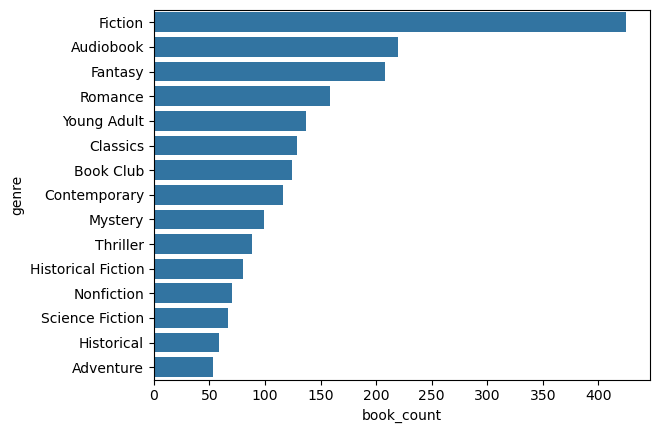

In [40]:
sns.barplot(
    data=top_genres,
    x="book_count",
    y="genre"
)